# ANN with SGD, Adam and RMSprop
**Aim:** Train an ANN with different optimizers and observe the effect of learning rate and batch size.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Load dataset
data = load_breast_cancer()

X = data.data
y = data.target

# Train and test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Validation data
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [3]:
# ANN model
def create_model(optimizer):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(16, activation='relu', input_shape=(30,)),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [5]:
# Train with SGD, Adam and RMSprop

optimizers = {
    'SGD': tf.keras.optimizers.SGD(learning_rate=0.01),
    'Adam': tf.keras.optimizers.Adam(learning_rate=0.01),
    'RMSprop': tf.keras.optimizers.RMSprop(learning_rate=0.01)
}

histories = {}

for name, optimizer in optimizers.items():

    model = create_model(optimizer)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=32,
        verbose=0
    )

    histories[name] = history

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    print(name, "Accuracy =", round(accuracy * 100, 2), "%")

SGD Accuracy = 95.61 %
Adam Accuracy = 95.61 %
RMSprop Accuracy = 95.61 %


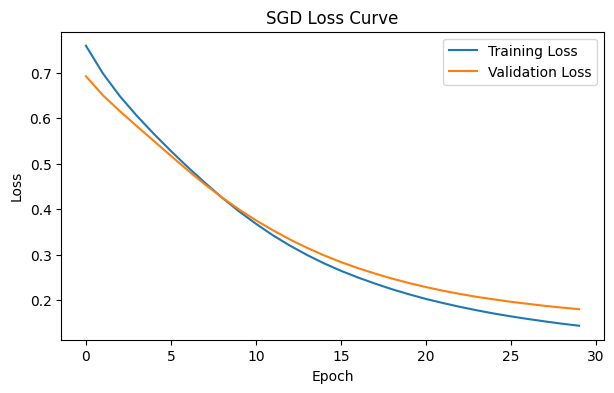

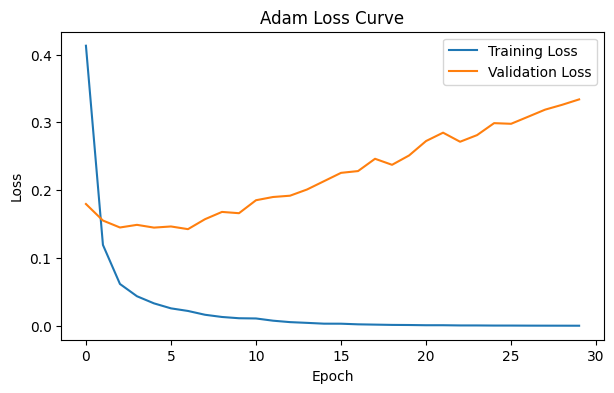

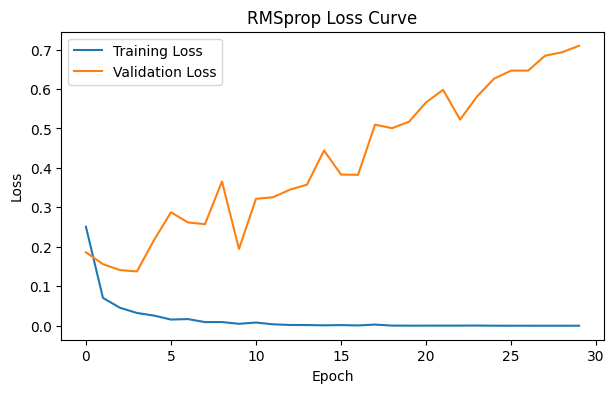

In [6]:
# Training and validation loss curves

for name, history in histories.items():

    plt.figure(figsize=(7, 4))

    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')

    plt.title(name + ' Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

## Effect of Learning Rate

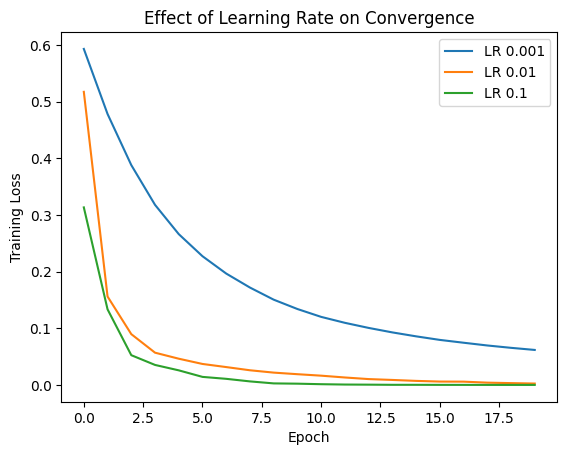

In [9]:
learning_rates = [0.001, 0.01, 0.1]

for lr in learning_rates:

    model = create_model(
        tf.keras.optimizers.Adam(learning_rate=lr)
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=32,
        verbose=0
    )

    plt.plot(history.history['loss'], label='LR ' + str(lr))

plt.title("Effect of Learning Rate on Convergence")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.show()

## Effect of Batch Size

In [8]:
batch_sizes = [16, 32, 64]

for batch in batch_sizes:

    model = create_model(
        tf.keras.optimizers.Adam(learning_rate=0.01)
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=batch,
        verbose=0
    )

    print("Batch Size:", batch)
    print("Final Training Loss:",
          round(history.history['loss'][-1], 4))
    print("Final Validation Loss:",
          round(history.history['val_loss'][-1], 4))
    print()

Batch Size: 16
Final Training Loss: 0.0006
Final Validation Loss: 0.2706

Batch Size: 32
Final Training Loss: 0.0024
Final Validation Loss: 0.2354

Batch Size: 64
Final Training Loss: 0.0037
Final Validation Loss: 0.2397



## Observation

- Compare the loss curves of SGD, Adam and RMSprop.
- A suitable learning rate gives smoother convergence.
- A very high learning rate can make training unstable.
- Batch size affects how often the weights are updated.
- Compare the final validation loss to observe convergence.